<a href="https://colab.research.google.com/github/Hemannshu/DataScience/blob/main/Healthcare_NLP_Chatbot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import pickle


In [9]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [11]:
import json

with open('/content/New Text Document.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data['intents'])
df

,tag,patterns,responses,priority
0,immediate_crisis,"[I want to hurt myself, I can't go on, End it ...",[🚨 You're not alone. Please call the National ...,1.0
1,depression,"[I feel worthless, Can't get out of bed, Nothi...",[Depression can make everything feel heavy. Wh...,NaN
2,anxiety,"[Panic attack, I'm freaking out, Can't breathe...",[Let's ground you:\n1. Name 5 things you see\n...,NaN
3,sleep_issues,"[Can't sleep, Insomnia, Nightmares, Waking up ...","[Sleep hygiene tips:\n• Cool, dark room\n• No ...",NaN
4,self_care,"[How to take care of myself?, Basic self-care,...",[Tiny self-care steps:\n1. Drink water\n2. Eat...,NaN
5,cbt_help,"[Negative thoughts, Cognitive distortions, Eve...",[Let's examine that thought:\n1. What's the ev...,NaN
6,mindfulness,"[Stay present, Grounding techniques, Dissociat...",[54321 Grounding:\n5 things you see\n4 things ...,NaN
7,toxic_relationships,"[Abusive partner, Emotional manipulation, Gasl...",[Signs of unhealthy relationships:\n• Constant...,NaN
8,therapy_info,"[Find a therapist, Can't afford counseling, Wh...",[Finding help:\n• PsychologyToday.com\n• OpenP...,NaN
9,progress_setbacks,"[I was doing better, Relapse, Back to square o...","[Recovery isn't linear. Even with setbacks, yo...",NaN


In [12]:
dic = {"tag":[], "patterns":[], "responses":[]}
for i in range(len(df)):
    ptrns = df[df.index == i]['patterns'].values[0]
    rspns = df[df.index == i]['responses'].values[0]
    tag = df[df.index == i]['tag'].values[0]
    for j in range(len(ptrns)):
        dic['tag'].append(tag)
        dic['patterns'].append(ptrns[j])
        dic['responses'].append(rspns)

df = pd.DataFrame.from_dict(dic)
df

,tag,patterns,responses
0,immediate_crisis,I want to hurt myself,[🚨 You're not alone. Please call the National ...
1,immediate_crisis,I can't go on,[🚨 You're not alone. Please call the National ...
2,immediate_crisis,End it all,[🚨 You're not alone. Please call the National ...
3,immediate_crisis,Suicidal thoughts,[🚨 You're not alone. Please call the National ...
4,immediate_crisis,No reason to live,[🚨 You're not alone. Please call the National ...
5,immediate_crisis,I'm a burden,[🚨 You're not alone. Please call the National ...
6,depression,I feel worthless,[Depression can make everything feel heavy. Wh...
7,depression,Can't get out of bed,[Depression can make everything feel heavy. Wh...
8,depression,Nothing matters,[Depression can make everything feel heavy. Wh...
9,depression,So depressed,[Depression can make everything feel heavy. Wh...


In [13]:
df['tag'].unique()


array(['immediate_crisis', 'depression', 'anxiety', 'sleep_issues',
       'self_care', 'cbt_help', 'mindfulness', 'toxic_relationships',
       'therapy_info', 'progress_setbacks', 'safety_emergency',
       'validation', 'mental_health_resources'], dtype=object)

In [14]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(lower=True, split=' ')
tokenizer.fit_on_texts(df['patterns'])
tokenizer.get_config()

{'num_words': None,
 'filters': '!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
 'lower': True,
 'split': ' ',
 'char_level': False,
 'oov_token': None,
 'document_count': 58,
 'word_counts': '{"i": 5, "want": 1, "to": 6, "hurt": 1, "myself": 2, "can\'t": 5, "go": 1, "on": 2, "end": 1, "it": 1, "all": 1, "suicidal": 1, "thoughts": 2, "no": 1, "reason": 1, "live": 1, "i\'m": 4, "a": 2, "burden": 1, "feel": 2, "worthless": 1, "get": 1, "out": 2, "of": 2, "bed": 1, "nothing": 1, "matters": 1, "so": 2, "depressed": 1, "why": 2, "even": 1, "try": 1, "panic": 1, "attack": 1, "freaking": 1, "breathe": 1, "heart": 1, "racing": 1, "anxious": 2, "spiral": 1, "sleep": 1, "insomnia": 1, "nightmares": 1, "waking": 1, "up": 1, "exhausted": 1, "but": 1, "wired": 1, "how": 1, "take": 1, "care": 2, "basic": 1, "self": 1, "too": 1, "tired": 1, "function": 1, "neglecting": 1, "needs": 1, "negative": 1, "cognitive": 1, "distortions": 1, "everything\'s": 1, "awful": 1, "mind": 1, "reading": 1, "catastrophizing": 1

In [15]:
vacab_size = len(tokenizer.word_index)
print('number of unique words = ', vacab_size)

number of unique words =  125


In [16]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

ptrn2seq = tokenizer.texts_to_sequences(df['patterns'])
X = pad_sequences(ptrn2seq, padding='post')
print('X shape = ', X.shape)

lbl_enc = LabelEncoder()
y = lbl_enc.fit_transform(df['tag'])
print('y shape = ', y.shape)
print('num of classes = ', len(np.unique(y)))

X shape =  (58, 6)
y shape =  (58,)
num of classes =  13


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 6, 100)         │        12,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 6, 32)          │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 6, 32)          │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 6, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_1           │ (None, 6, 32)          │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 128)            │           256 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,381 (271.02 KB)

 Trainable params: 69,381 (271.02 KB)

 Non-trainable params: 0 (0.00 B)

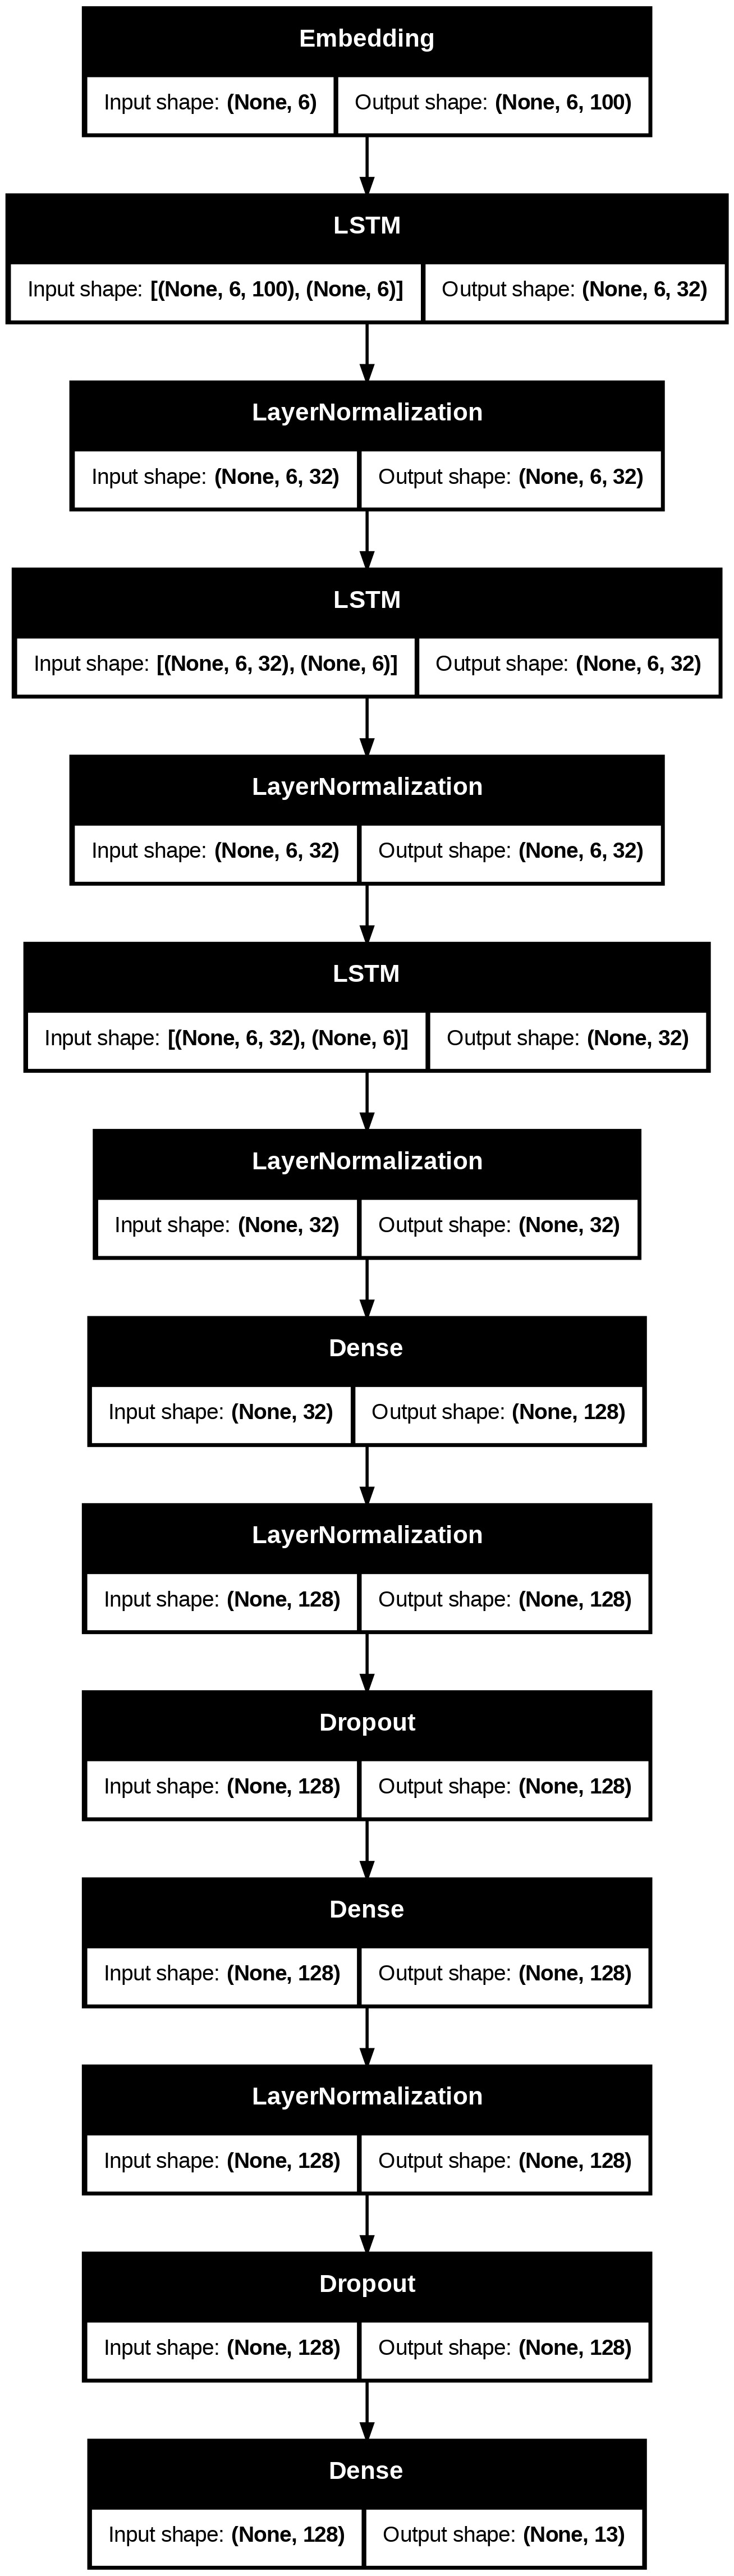

In [17]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, LayerNormalization, Dense, Dropout
from tensorflow.keras.utils import plot_model

model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Embedding(input_dim=vacab_size+1, output_dim=100, mask_zero=True))
model.add(LSTM(32, return_sequences=True))
model.add(LayerNormalization())
model.add(LSTM(32, return_sequences=True))
model.add(LayerNormalization())
model.add(LSTM(32))
model.add(LayerNormalization())
model.add(Dense(128, activation="relu"))
model.add(LayerNormalization())
model.add(Dropout(0.2))
model.add(Dense(128, activation="relu"))
model.add(LayerNormalization())
model.add(Dropout(0.2))
model.add(Dense(len(np.unique(y)), activation="softmax"))
model.compile(optimizer='adam', loss="sparse_categorical_crossentropy", metrics=['accuracy'])

model.summary()
plot_model(model, show_shapes=True)

In [18]:
model_history = model.fit(x=X,
                          y=y,
                          batch_size=10,
                          callbacks=[tensorflow.keras.callbacks.EarlyStopping(monitor='accuracy', patience=3)],
                          epochs=50)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.0453 - loss: 3.5979
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.2876 - loss: 1.9730
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4182 - loss: 1.5627
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6370 - loss: 1.1522
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7425 - loss: 0.8448
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8432 - loss: 0.6754
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9015 - loss: 0.5542
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9097 - loss: 0.4408
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9171 - loss: 0.3697
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.1733
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9690 - loss: 0.3119
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9886 - loss: 0.1845


In [19]:
import re
import random

def generate_answer(pattern):
    text = []
    txt = re.sub('[^a-zA-Z\']', ' ', pattern)
    txt = txt.lower()
    txt = txt.split()
    txt = " ".join(txt)
    text.append(txt)

    x_test = tokenizer.texts_to_sequences(text)
    x_test = np.array(x_test).squeeze()
    x_test = pad_sequences([x_test], padding='post', maxlen=X.shape[1])
    y_pred = model.predict(x_test)
    y_pred = y_pred.argmax()
    tag = lbl_enc.inverse_transform([y_pred])[0]
    responses = df[df['tag'] == tag]['responses'].values[0]

    print("you: {}".format(pattern))
    print("model: {}".format(random.choice(responses)))

In [25]:
generate_answer('I want to hurt myself')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
you: I want to hurt myself
model: This is serious. I'm sharing these resources right now:
• Text HOME to 741741 (Crisis Text Line)
• Call 988 (24/7 Suicide Prevention)


In [21]:
generate_answer('difference between sadness and depression')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
you: difference between sadness and depression
model: Anxiety feels awful but isn't dangerous. Try the 5-5-5 method:
• 5 slow breaths
• 5 facts about your surroundings
• 5 gentle body stretches


In [22]:
generate_answer('I am feeling sad')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
you: I am feeling sad
model: Compare yourself to past you, not others. What's one tiny thing better than your worst day?


In [23]:
generate_answer('I am feeling depressed')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
you: I am feeling depressed
model: That sounds incredibly hard. Remember depression lies to you - this pain isn't permanent. Have you spoken to a doctor about how you're feeling?


In [26]:
generate_answer("Having a panic attack")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
you: Having a panic attack
model: Depression can make everything feel heavy. What you're experiencing is real and treatable. Would you like:
1. Coping strategies
2. Professional resources
3. Just to talk?


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [28]:
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_test, y_test))


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 218ms/step - accuracy: 0.9858 - loss: 0.1383 - val_accuracy: 1.0000 - val_loss: 0.0344
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 1.0000 - loss: 0.0895 - val_accuracy: 1.0000 - val_loss: 0.0340
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.0904 - val_accuracy: 1.0000 - val_loss: 0.0346
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0763 - val_accuracy: 1.0000 - val_loss: 0.0351
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0788 - val_accuracy: 1.0000 - val_loss: 0.0348
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.0579 - val_accuracy: 1.0000 - val_loss: 0.0336
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0404 - val_accuracy: 1.0000 - val_loss: 0.0336
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.0331 - val_accuracy: 1.0000 - val_loss

In [29]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy * 100:.2f}%')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9167 - loss: 0.2027
Test Accuracy: 91.67%


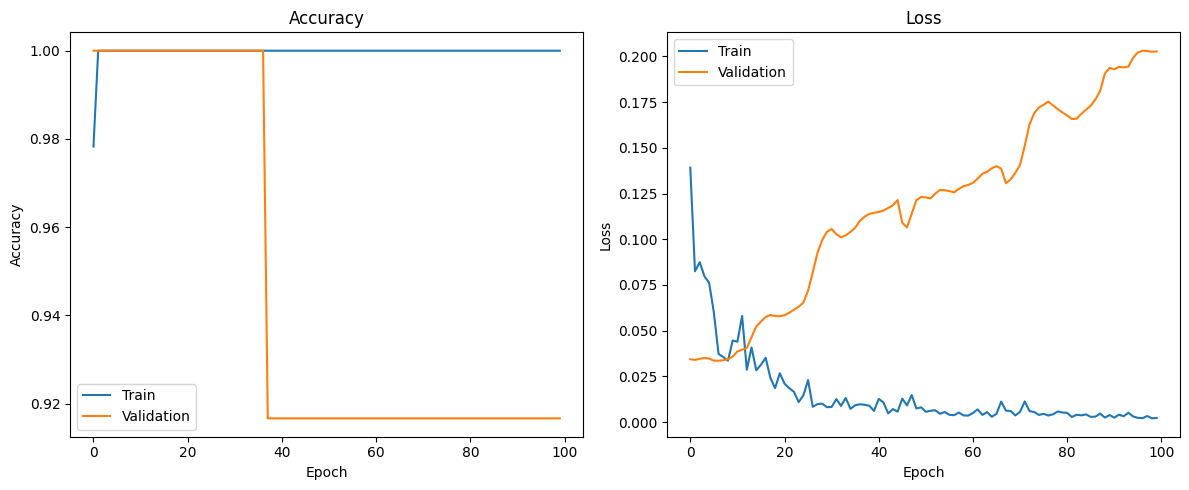

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         3
           4       0.00      0.00      0.00         0
           6       1.00      1.00      1.00         1
           7       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         1

    accuracy                           0.92        12
   macro avg       0.88      0.81      0.83        12
weighted avg       1.00      0.92      0.94        12

Confusion Matrix:

[[1 0 0 1 0 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 3 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 2 0 0]
 [0 0 0 0 0 0 2 0]
 [0 0 0 0 0 0 0 1]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
